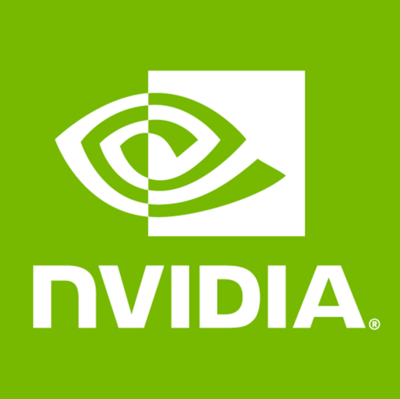

# Kaggle NVIDIA Nemotron Model Reasoning Challenge
Advance reasoning techniques using NVIDIA Nemotron open models on a novel benchmark
[Competition Link](https://www.kaggle.com/competitions/nvidia-nemotron-model-reasoning-challenge/overview)


In [1]:
!pip install -q --no-index --find-links /kaggle/input/datasets/dennisfong/nvidia-nemotron-offline-packages/offline_packages datasets trl --ignore-installed

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
torchvision 0.26.0.dev20260324+cu128 requires torch==2.12.0.dev20260324, but you have torch 2.11.0 which is incompatible.
cuda-python 12.9.6 requires cuda-bindings~=12.9.6, but you have cuda-bindings 13.2.0 which is incompatible.
ydata-profiling 4.18.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.4 which is incompatible.
ydata-profiling 4.18.1 requires pandas!=1.4.0,<3.0,>1.5, but you have pandas 3.0.1 which is incompatible.
ydata-profiling 4.18.1 requires scipy<1.17,>=1.8, but you have scipy 1.17.1 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatibl

In [2]:
import datasets
import trl
print("Successfully imported datasets version:", datasets.__version__)
print("Successfully imported trl version:", trl.__version__)

import multiprocessing
multiprocessing.cpu_count()

Successfully imported datasets version: 4.8.4
Successfully imported trl version: 0.29.1


48

In [3]:
import os
import sys
import stat
import shutil
import gc
import zipfile
import polars as pl
import torch
import torch.nn.functional as F
import kagglehub
from datasets import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments
from peft import LoraConfig, get_peft_model, TaskType
from trl import SFTTrainer, SFTConfig


# --- Kaggle / Triton Environment Fixes ---
# Bypass Triton rmsnorm (avoids ptxas-blackwell permission issue)
def _pure_rmsnorm_fn(x, weight, bias=None, z=None, eps=1e-5,
                     group_size=None, norm_before_gate=True, upcast=True):
    dtype = x.dtype
    if upcast:
        x = x.float()
    variance = x.pow(2).mean(-1, keepdim=True)
    x_normed = x * torch.rsqrt(variance + eps)
    out = x_normed * weight.float()
    if bias is not None:
        out = out + bias.float()
    if z is not None:
        out = out * F.silu(z.float())
    return out.to(dtype)

for name, mod in list(sys.modules.items()):
    if hasattr(mod, 'rmsnorm_fn'):
        mod.rmsnorm_fn = _pure_rmsnorm_fn

# Copy PTXAS binaries to a writable temp directory
src = "/kaggle/usr/lib/notebooks/ryanholbrook/nvidia-utility-script/triton/backends/nvidia/bin/ptxas-blackwell"
dst = "/tmp/ptxas-blackwell"
if os.path.exists(src):
    shutil.copy2(src, dst)
    os.chmod(dst, os.stat(dst).st_mode | stat.S_IEXEC | stat.S_IXGRP | stat.S_IXOTH)

    import triton.backends.nvidia as nv_backend
    src_bin = os.path.join(os.path.dirname(nv_backend.__file__), "bin")
    dst_bin = "/tmp/triton_nvidia_bin"
    shutil.copytree(src_bin, dst_bin, dirs_exist_ok=True)
    for f in os.listdir(dst_bin):
        fp = os.path.join(dst_bin, f)
        if os.path.isfile(fp):
            os.chmod(fp, os.stat(fp).st_mode | stat.S_IEXEC | stat.S_IXGRP | stat.S_IXOTH)

    nv_backend.__file__ = os.path.join(dst_bin, "..", "__init__.py")
    os.environ["TRITON_PTXAS_PATH"] = dst



os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

OUTPUT_DIR = "/kaggle/working/adapter"
os.makedirs(OUTPUT_DIR, exist_ok=True)

/kaggle/usr/lib/notebooks/ryanholbrook/nvidia_utility_script/torch/compiler/__init__.py:148: FutureWarning: torch._dynamo.allow_in_graph is deprecated and will be removed in a future version. Use torch._dynamo.nonstrict_trace instead.
  return torch._dynamo.allow_in_graph(fn)


In [4]:
import sys
import types

for _mod_name in [
    'mamba_ssm.modules.mamba3',
    'mamba_ssm.ops.cute',
    'mamba_ssm.ops.cute.mamba3',
    'mamba_ssm.ops.cute.mamba3.mamba3_step_fn',
]:
    sys.modules[_mod_name] = types.ModuleType(_mod_name)
# Give mamba3 a dummy Mamba3 class so the __init__ import doesn't fail
sys.modules['mamba_ssm.modules.mamba3'].Mamba3 = None

In [5]:
import polars as pl
train = pl.read_csv('/kaggle/input/competitions/nvidia-nemotron-model-reasoning-challenge/train.csv')
train.head()

id,prompt,answer
str,str,str
"""00066667""","""In Alice's Wonderland, a secre…","""10010111"""
"""000b53cf""","""In Alice's Wonderland, a secre…","""01000011"""
"""00189f6a""","""In Alice's Wonderland, secret …","""cat imagines book"""
"""001b24c4""","""In Alice's Wonderland, numbers…","""XXXVIII"""
"""001c63cb""","""In Alice's Wonderland, secret …","""wizard creates secret"""


# Loading Nemotron Model

In [6]:
# --- Hyperparameters ---
SUBSAMPLE_SIZE = 600
LORA_RANK = 32
MAX_SEQ_LEN = 2048 #1024 
NUM_EPOCHS = 2 
GRAD_ACCUM = 4
LR = 2e-4 #1e-4 #2e-4

# Configuration
MODEL_PATH = kagglehub.model_download("metric/nemotron-3-nano-30b-a3b-bf16/transformers/default")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    device_map="auto",
    trust_remote_code=True,
    dtype=torch.bfloat16
)
# tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, trust_remote_code=True)
print("Model loaded successfully.")

# Force slow path — bypass the broken CUDA kernels
for name, mod in sys.modules.items():
    if "modeling_nemotron_h" in name:
        mod.is_fast_path_available = False
        print(f"Patched {name}: is_fast_path_available = False")

# Initialize LoRA Adapter
print(f"Initializing LoRA adapter with rank={LORA_RANK}...")
lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=16,
    target_modules=r".*\.(in_proj|out_proj|up_proj|down_proj)$",
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

# Apply LoRA to the model
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

Loading weights:   0%|          | 0/6243 [00:00<?, ?it/s]

Model loaded successfully.
Patched transformers_modules._1.modeling_nemotron_h: is_fast_path_available = False
Initializing LoRA adapter with rank=32...


/usr/local/lib/python3.12/dist-packages/torchao/float8/float8_tensor.py:122: FutureWarning: torch._dynamo.allow_in_graph is deprecated and will be removed in a future version. Use torch._dynamo.nonstrict_trace instead.
  @torch._dynamo.allow_in_graph
/usr/local/lib/python3.12/dist-packages/torchao/float8/float8_tensor.py:195: FutureWarning: torch._dynamo.allow_in_graph is deprecated and will be removed in a future version. Use torch._dynamo.nonstrict_trace instead.
  @torch._dynamo.allow_in_graph
/usr/local/lib/python3.12/dist-packages/torchao/float8/float8_scaling_utils.py:90: FutureWarning: torch._dynamo.allow_in_graph is deprecated and will be removed in a future version. Use torch._dynamo.nonstrict_trace instead.
  @torch._dynamo.allow_in_graph
/usr/local/lib/python3.12/dist-packages/torchao/float8/float8_linear.py:60: FutureWarning: torch._dynamo.allow_in_graph is deprecated and will be removed in a future version. Use torch._dynamo.nonstrict_trace instead.
  @torch._dynamo.allow_

trainable params: 880,138,240 || all params: 32,458,075,584 || trainable%: 2.7116


# Training Nemotron Model

In [7]:
# YOUR CODE HERE
# --------------
# model.train() 
# --------------


# Save Adapter
print(f"Saving adapter to {OUTPUT_DIR}...")
model.save_pretrained(OUTPUT_DIR)

Saving adapter to /kaggle/working/adapter...


# Save and Package Submission

In [8]:
import subprocess

subprocess.run("zip -m submission.zip *", shell=True, check=True)

  adding: __notebook__.ipynb (deflated 46%)
  adding: adapter/ (stored 0%)


CompletedProcess(args='zip -m submission.zip *', returncode=0)